<a href="https://colab.research.google.com/github/pabloecheg/Unsupervised-Learning/blob/main/RETO_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install googletrans==4.0.0-rc1
!pip install language-tool-python
!pip install translate
!pip install unidecode
!pip install pyLDAvis

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.0 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17397 sha256=28d362d5a5428caaefa6af974e3d255223106e314ad13ad93add2501ef435299
  Stored in directory: /root/.cache/pip/wheels/c0/59/9f/7372f0cf70160fe61b528532e1a7c8498c4becd6bcffb022de
Successfully built googletrans
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:


In [ ]:
from google.colab import drive # conectar con datos de drive
drive.mount('/content/gdrive')
from googletrans import Translator
import language_tool_python
import pandas as pd # manejo de data frame
import numpy as np # manejos matriciales
import nltk # paquete 1 de lenguaje natural
import spacy # paquete 2 de lenguaje natural
import re # paquete 2 de lenguaje natural
from textblob import TextBlob  #
from unidecode import unidecode
import seaborn as sns # graficos
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords # conjunto de stopwords
from nltk.tokenize import TweetTokenizer # tokenizador de tweet
from nltk.stem import PorterStemmer # hacer steming palabras
from nltk.stem import LancasterStemmer # hacer steming palabras
from nltk.stem import WordNetLemmatizer # extraer el lema de una palabra
import matplotlib.pyplot as plt
from transformers import pipeline
from wordcloud import WordCloud  # graficos de palabras
from transformers import MarianMTModel, MarianTokenizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')
# from translate import Translator
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN)
from sklearn.decomposition import PCA # Análisis de componentes principales
from scipy.cluster.hierarchy import dendrogram,  linkage # Dendograma
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
datos = pd.read_csv('/content/gdrive/MyDrive/APRENDIZAJE NO SUPERVISADO/BASES DE DATOS/realdonaldtrump.csv')

In [ ]:
datos.columns

Index(['id', 'link', 'content', 'date', 'retweets', 'favorites', 'mentions',
       'hashtags'],
      dtype='object')

In [ ]:
datos_muestra=datos.sample(1000, random_state=1017923112)

In [ ]:
datos_muestra.head()

,id,link,content,date,retweets,favorites,mentions,hashtags
8626,327846664712880129,https://twitter.com/realDonaldTrump/status/327...,Does Bush’s library have a wing featuring Supr...,2013-04-26 13:08:30,61,55,NaN,NaN
27882,699989532180135936,https://twitter.com/realDonaldTrump/status/699...,Jeb Bush just got contact lenses and got rid o...,2016-02-17 10:11:24,7745,15126,NaN,NaN
4320,265460364307746816,https://twitter.com/realDonaldTrump/status/265...,@ Lorrainejuliet @ EDLTrobinson @ FloridaJayha...,2012-11-05 08:27:37,3,0,"@EDLTrobinson,@FloridaJayhawk,@hannityshow",NaN
23075,605454865213628416,https://twitter.com/realDonaldTrump/status/605...,Entrepreneurs: There's nothing wrong with brin...,2015-06-01 14:24:23,212,276,NaN,NaN
24618,634576881011064832,https://twitter.com/realDonaldTrump/status/634...,"@ ABCPolitics must apologize. My statement ""we...",2015-08-20 23:04:52,579,635,NaN,NaN


### Analisis de Sentimiento

In [ ]:
sia = SentimentIntensityAnalyzer() # Definimos el algoritmo base.
def analisis_sentimiento(texto ):
  """
  Recibe un texto
  Retorna el sentimiento del texto, negativo, positivo, neutral
  """
  sentimiento = sia.polarity_scores(texto)['compound']  # Devuelve un diccionario con los resultados}
  if sentimiento >0: # si es >0, es positivo
    etiqueta= "positivo"
  elif sentimiento <0: # si es <0, es negativo
    etiqueta= "negativo"
  else: # en caso contrario = 0, es neutral.
    etiqueta= "neutral"
  return etiqueta

<Axes: xlabel='sentimiento'>

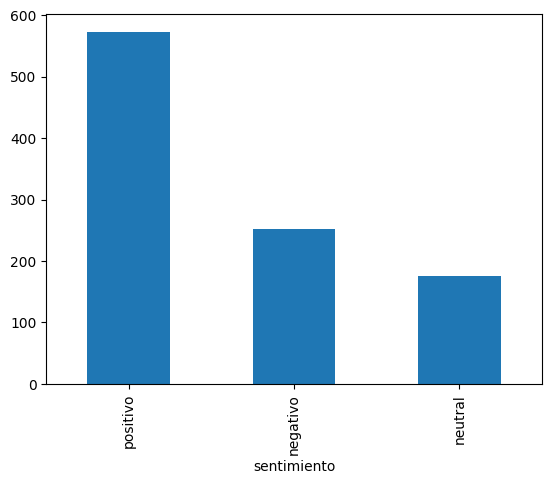

In [ ]:
datos_muestra["sentimiento"].value_counts().plot(kind="bar")

En total, hay muchisimos mas tweets positivos.

### Extraccion de Entidades

In [ ]:
nlp = spacy.load("en_core_web_sm") # lectura del modelo
def extraer_entidades(texto):
  """
  Por cada noticia vamos a extraer la entidad de ORG, GPE y PERSON
  Retorna un texto con las entidades separadas por ,
  """
  doc = nlp(texto) # aplicamos el algoritmo
  entidades=[] # entidades
  # entidades=[w.text for w in doc.ents if w.label_  in ["ORG", "GPE", "PERSON"]]
  for ent in doc.ents:
    if ent.label_  in ["PRODUCT", "PERSON"]:
      entidades.append(ent.text) # añadimos a la lista
  entidades=','.join(entidades) # unimos la lista por comas
  entidades=entidades.lower() # todo a minúsculas
  return entidades

In [ ]:
datos_muestra["entidades"]=datos_muestra["content"].apply(extraer_entidades)

In [ ]:
datos_muestra

,id,link,content,date,retweets,favorites,mentions,hashtags,sentimiento,entidades
8626,327846664712880129,https://twitter.com/realDonaldTrump/status/327...,Does Bush’s library have a wing featuring Supr...,2013-04-26 13:08:30,61,55,NaN,NaN,positivo,"bush,jon robert,roberts"
27882,699989532180135936,https://twitter.com/realDonaldTrump/status/699...,Jeb Bush just got contact lenses and got rid o...,2016-02-17 10:11:24,7745,15126,NaN,NaN,positivo,jeb bush
4320,265460364307746816,https://twitter.com/realDonaldTrump/status/265...,@ Lorrainejuliet @ EDLTrobinson @ FloridaJayha...,2012-11-05 08:27:37,3,0,"@EDLTrobinson,@FloridaJayhawk,@hannityshow",NaN,positivo,
23075,605454865213628416,https://twitter.com/realDonaldTrump/status/605...,Entrepreneurs: There's nothing wrong with brin...,2015-06-01 14:24:23,212,276,NaN,NaN,positivo,
24618,634576881011064832,https://twitter.com/realDonaldTrump/status/634...,"@ ABCPolitics must apologize. My statement ""we...",2015-08-20 23:04:52,579,635,NaN,NaN,negativo,
...,...,...,...,...,...,...,...,...,...,...
38764,1162175486560280577,https://twitter.com/realDonaldTrump/status/116...,Thank you New Hampshire. KEEP AMERICA GREAT! #...,2019-08-15 20:33:22,18942,85375,NaN,#KAG2020pic,positivo,
1966,199315571484004352,https://twitter.com/realDonaldTrump/status/199...,How will the client react? They’ve got both El...,2012-05-06 20:51:50,15,4,NaN,#sweepstweet,positivo,chi
41455,1227432921788801024,https://twitter.com/realDonaldTrump/status/122...,Bootedgeedge (Buttigieg) is doing pretty well ...,2020-02-11 21:23:07,14799,89065,NaN,NaN,positivo,bernie
41034,1216399515948867588,https://twitter.com/realDonaldTrump/status/121...,Why should I have the stigma of Impeachment at...,2020-01-12 10:40:18,31319,155491,NaN,NaN,negativo,hoax


Size of new BoW title = 344


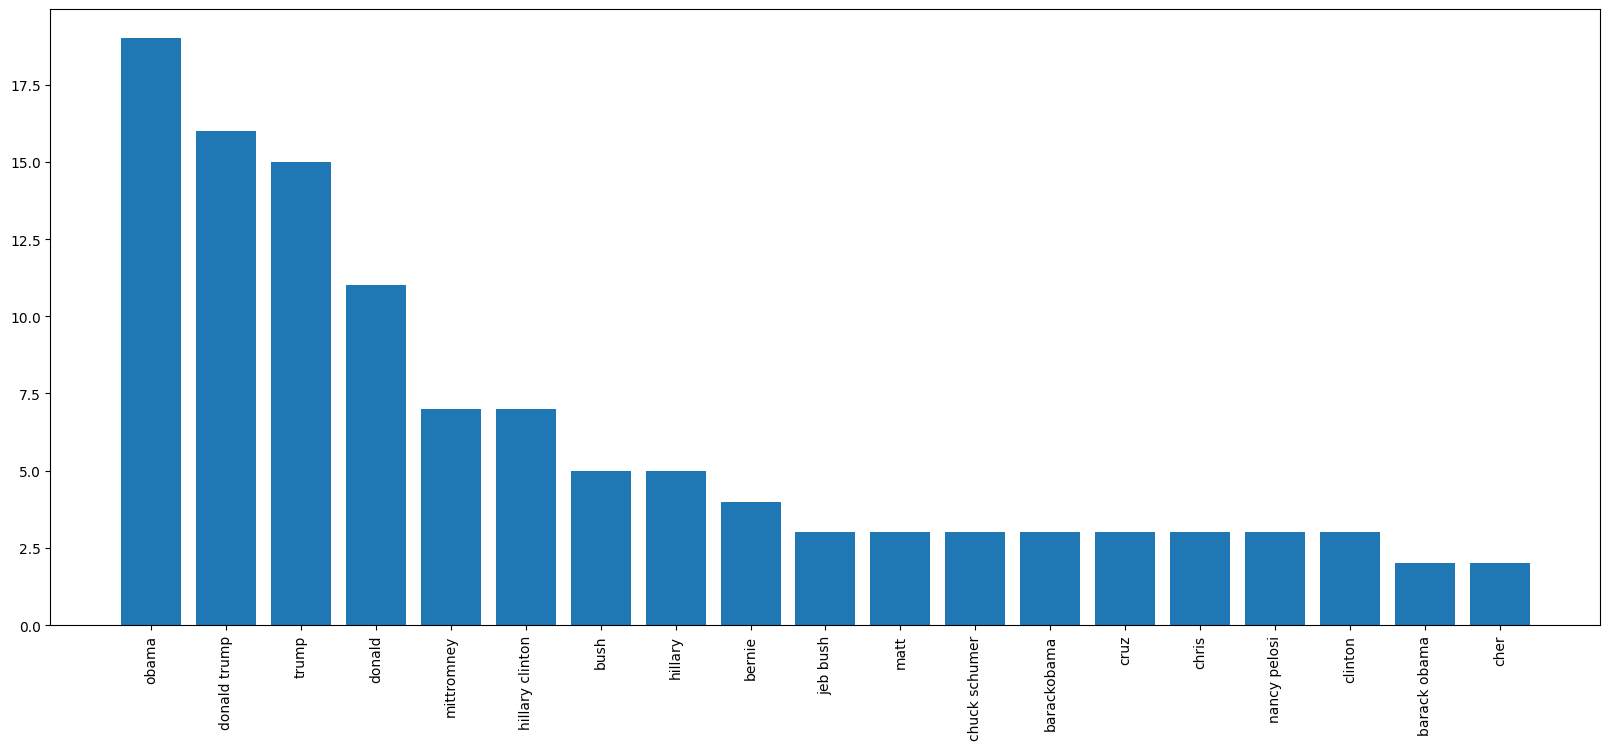

In [ ]:
texto_entidades=','.join(datos_muestra["entidades"])
texto_entidades = texto_entidades.split(',')
fdist = nltk.FreqDist(texto_entidades)
topwords = fdist.most_common(20)
print('Size of new BoW title =',len(fdist))
x,y = zip(*topwords)

plt.figure(figsize=(20,8))
plt.bar(x[1:],y[1:])
plt.xticks(rotation=90)
plt.show()

La mayoría de entidades que se logra reconocer, gira en torno a la política.

### Limpieza

In [ ]:
stop_words_nltk_en =list(set(stopwords.words('english')))
stop_words_nltk_en = ["u", "ok", *stop_words_nltk_en]
stop_words_nltk_es =list(set(stopwords.words('spanish')))
def texto_limpio(texto, idioma ="en"):
  """
  Recibe un texto
  Retorna un texto sin simbolos, sin stopwords, en minusculas
  idioma = en (inglés) o es (español)
  """
  texto_limpio=str(texto).lower()
  # blob = TextBlob(texto_limpio )
  # texto_limpio= blob.correct().string
  if idioma=="es":
    texto_limpio = unidecode(texto_limpio) # elimina los acentos y ñ
  texto_limpio= re.sub(r'https?://\S+|www\.\S+', ' ', texto_limpio)  # eliminar la URL
  texto_limpio= re.sub(r"[^A-Za-z]+",' ',texto_limpio) # Eliminar simbolos
  texto_limpio = texto_limpio.split() # seperacion de tokens
  if idioma=="en":
    texto_limpio=[w for w in texto_limpio if w not in stop_words_nltk_en] # eliminacción de stop word
  elif idioma=="es":
    texto_limpio=[w for w in texto_limpio if w not in stop_words_nltk_es] # eliminacción de stop word
  texto_limpio=' '.join(texto_limpio)
  return texto_limpio

In [ ]:
datos_muestra["content_limpio"]=datos_muestra["content"].apply(texto_limpio)

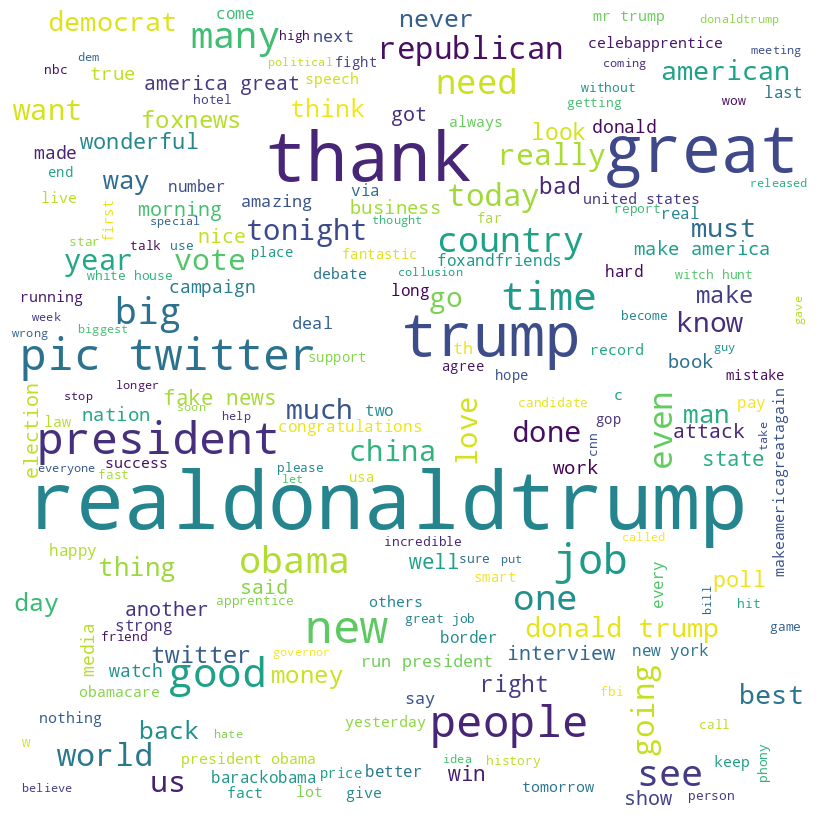

In [ ]:
texto_join =  " ".join(datos_muestra["content_limpio"])
wordcloud = WordCloud(width = 800, height = 800, background_color ='white', min_font_size = 10).generate(texto_join)
 # mostrar nube de palabras
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

### Relacion entre Favoritos y Retweets

Para resolver el problema de escala, ya que hay tweets que generan desde 0 hasta 400.000 retweets, usamos esta función logaritmica para que quede en una escala mas fácil de visualizar.

<Axes: xlabel='sentimiento', ylabel='LogFav'>

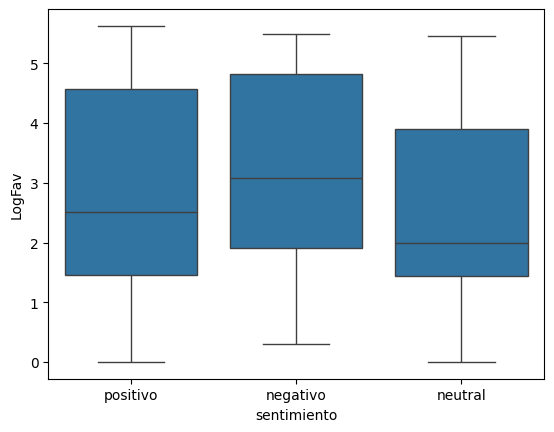

In [ ]:
datos_muestra['LogFav'] = np.log10(datos_muestra['favorites']+1)
sns.boxplot(x="sentimiento", y="LogFav", data=datos_muestra)

<Axes: xlabel='sentimiento', ylabel='LogRetw'>

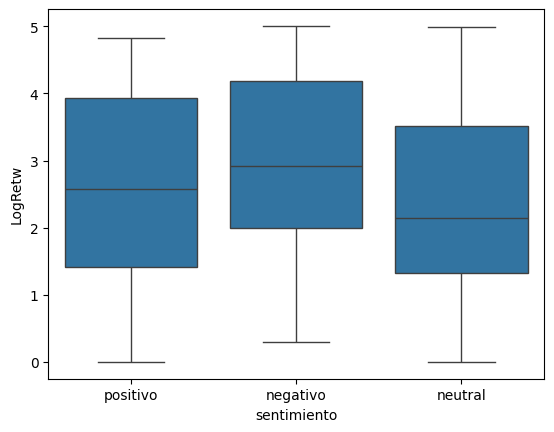

In [ ]:
datos_muestra['LogRetw'] = np.log10(datos_muestra['retweets']+1)
sns.boxplot(x="sentimiento", y="LogRetw", data=datos_muestra)

Como podemos ver, los tweets negativos generan en total más interacciones que los tweets positivos o negativos. El comportamiento entre retweets y favoritos es muy similar, ya que están altamente relacionadas.